In [1]:
# ── Setup — install only what's missing ──────────────────────────────────────
# !pip install scikit-learn statsmodels lime matplotlib pandas numpy

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.datasets import (
    load_iris, load_wine, load_breast_cancer,
    make_blobs, make_classification, make_regression, fetch_openml
)
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.compose import ColumnTransformer
from sklearn.metrics import (
    accuracy_score, silhouette_score,
    adjusted_rand_score, mean_squared_error
)
import sklearn
print('✅ All imports OK')
print(f'   scikit-learn: {sklearn.__version__}')

✅ All imports OK
   scikit-learn: 1.8.0


In [2]:
# ── 1.1  Load Titanic (fast from sklearn cache) ───────────────────────────────
X_raw, y_raw = fetch_openml('titanic', version=1, as_frame=True, return_X_y=True)

# Keep useful columns only
FEATURES = ['pclass', 'age', 'sibsp', 'parch', 'fare', 'sex', 'embarked']
X = X_raw[FEATURES].copy()
y = y_raw.astype(int)

print('Shape:', X.shape)
print('Missing values:')
print(X.isnull().sum())
print('\nSurvival rate:', y.mean().round(3))

Shape: (1309, 7)
Missing values:
pclass        0
age         263
sibsp         0
parch         0
fare          1
sex           0
embarked      2
dtype: int64

Survival rate: 0.382


In [3]:
# ── 1.2  Build ColumnTransformer + Pipeline ───────────────────────────────────
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.linear_model import LogisticRegression

num_cols = ['age', 'fare', 'sibsp', 'parch', 'pclass']
cat_cols = ['sex', 'embarked']

# Numeric: impute median → scale
num_pipe = make_pipeline(
    SimpleImputer(strategy='median'),
    StandardScaler()
)
# Categorical: impute mode → one-hot encode
cat_pipe = make_pipeline(
    SimpleImputer(strategy='most_frequent'),
    OneHotEncoder(handle_unknown='ignore', sparse_output=False)
)

preprocessor = ColumnTransformer([
    ('num', num_pipe, num_cols),
    ('cat', cat_pipe, cat_cols)
])

# Full pipeline: preprocessing + classifier
pipe_gb  = Pipeline([('prep', preprocessor), ('clf', GradientBoostingClassifier(n_estimators=80, random_state=42))])
pipe_rf  = Pipeline([('prep', preprocessor), ('clf', RandomForestClassifier(n_estimators=80, random_state=42))])
pipe_lr  = Pipeline([('prep', preprocessor), ('clf', LogisticRegression(max_iter=500))])

print('Pipelines defined. No data leakage possible!')
print(pipe_gb)

Pipelines defined. No data leakage possible!
Pipeline(steps=[('prep',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('simpleimputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('standardscaler',
                                                                   StandardScaler())]),
                                                  ['age', 'fare', 'sibsp',
                                                   'parch', 'pclass']),
                                                 ('cat',
                                                  Pipeline(steps=[('simpleimputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehotencoder',
                                 

In [4]:
# ── 1.3  Cross-Validate All Pipelines ────────────────────────────────────────
results = {}
for name, pipe in [('GradientBoosting', pipe_gb), ('RandomForest', pipe_rf), ('LogisticReg', pipe_lr)]:
    scores = cross_val_score(pipe, X, y, cv=5, scoring='accuracy')
    results[name] = scores
    print(f'{name:20s}: {scores.mean():.4f} ± {scores.std():.4f}')

GradientBoosting    : 0.6852 ± 0.1049
RandomForest        : 0.6570 ± 0.0798
LogisticReg         : 0.7227 ± 0.1100


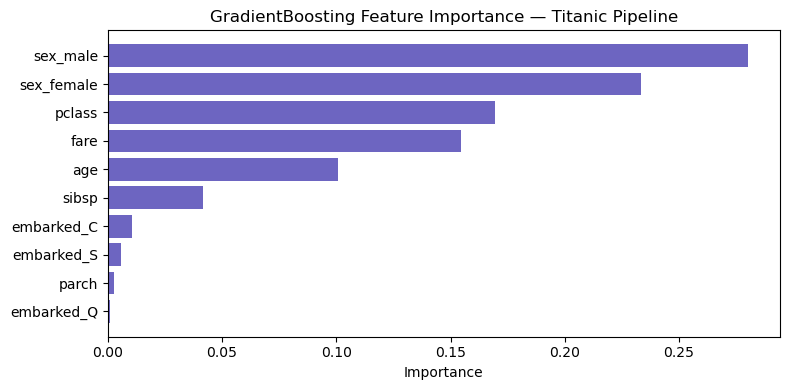

In [5]:
# ── 1.4  Feature Importance from Pipeline ────────────────────────────────────
pipe_gb.fit(X, y)

# Recover feature names after ColumnTransformer
cat_names = pipe_gb.named_steps['prep'].named_transformers_['cat']\
                   .named_steps['onehotencoder'].get_feature_names_out(cat_cols).tolist()
feat_names = num_cols + cat_names
importances = pipe_gb.named_steps['clf'].feature_importances_

imp_df = pd.DataFrame({'feature': feat_names, 'importance': importances})\
           .sort_values('importance', ascending=True).tail(10)

fig, ax = plt.subplots(figsize=(8, 4))
ax.barh(imp_df['feature'], imp_df['importance'], color='#534AB7', alpha=0.85)
ax.set_title('GradientBoosting Feature Importance — Titanic Pipeline')
ax.set_xlabel('Importance')
plt.tight_layout(); plt.show()

In [6]:
# ── 1.5  Save & Reload Entire Pipeline ───────────────────────────────────────
import joblib

joblib.dump(pipe_gb, 'titanic_pipeline.pkl')
print('✅ Pipeline saved: titanic_pipeline.pkl')

# Reload and predict on a new passenger
loaded_pipe = joblib.load('titanic_pipeline.pkl')
new_passenger = pd.DataFrame([{
    'pclass': 1, 'age': 29.0, 'sibsp': 0, 'parch': 0,
    'fare': 211.3, 'sex': 'female', 'embarked': 'S'
}])
pred  = loaded_pipe.predict(new_passenger)[0]
proba = loaded_pipe.predict_proba(new_passenger)[0]
print(f'Prediction : {"Survived" if pred == 1 else "Did not survive"}')
print(f'Confidence : {proba.max():.2%}')

✅ Pipeline saved: titanic_pipeline.pkl
Prediction : Survived
Confidence : 93.15%


In [7]:
# ── 2.1  Generate Synthetic Clusters ─────────────────────────────────────────
from sklearn.cluster import KMeans, DBSCAN
from sklearn.preprocessing import StandardScaler

X_blobs, y_true = make_blobs(n_samples=600, centers=4, cluster_std=1.2, random_state=42)
X_sc = StandardScaler().fit_transform(X_blobs)

print(f'Dataset: {X_blobs.shape[0]} samples, {len(np.unique(y_true))} true clusters')

Dataset: 600 samples, 4 true clusters


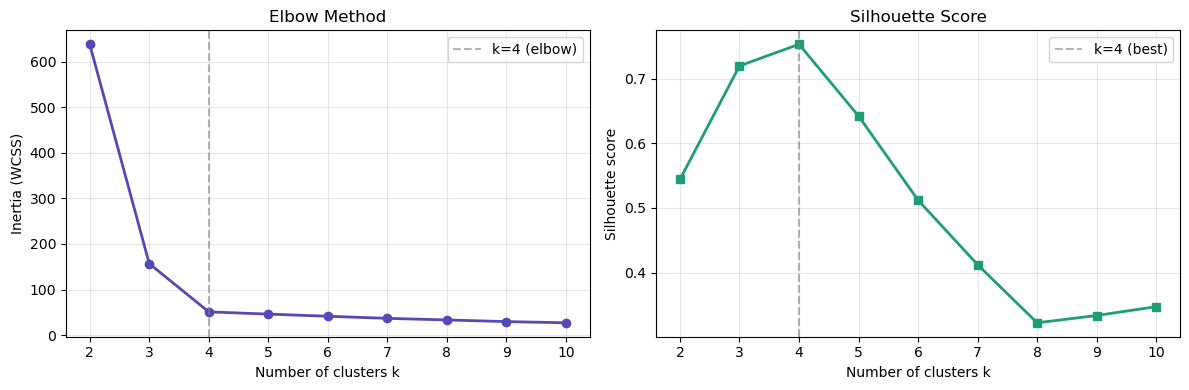

Best silhouette at k=4: 0.7531


In [8]:
# ── 2.2  Elbow Method to Find Optimal k ──────────────────────────────────────
k_range   = range(2, 11)
inertias  = []
sil_scores = []

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10).fit(X_sc)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X_sc, km.labels_))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(k_range, inertias, 'o-', color='#534AB7', linewidth=2)
axes[0].axvline(4, linestyle='--', color='gray', alpha=0.6, label='k=4 (elbow)')
axes[0].set_xlabel('Number of clusters k')
axes[0].set_ylabel('Inertia (WCSS)')
axes[0].set_title('Elbow Method')
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(k_range, sil_scores, 's-', color='#1D9E75', linewidth=2)
axes[1].axvline(4, linestyle='--', color='gray', alpha=0.6, label='k=4 (best)')
axes[1].set_xlabel('Number of clusters k')
axes[1].set_ylabel('Silhouette score')
axes[1].set_title('Silhouette Score')
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout(); plt.show()
print(f'Best silhouette at k=4: {sil_scores[2]:.4f}')

K-Means  — ARI: 0.9955
DBSCAN   — ARI: 0.7133
DBSCAN noise points: 0


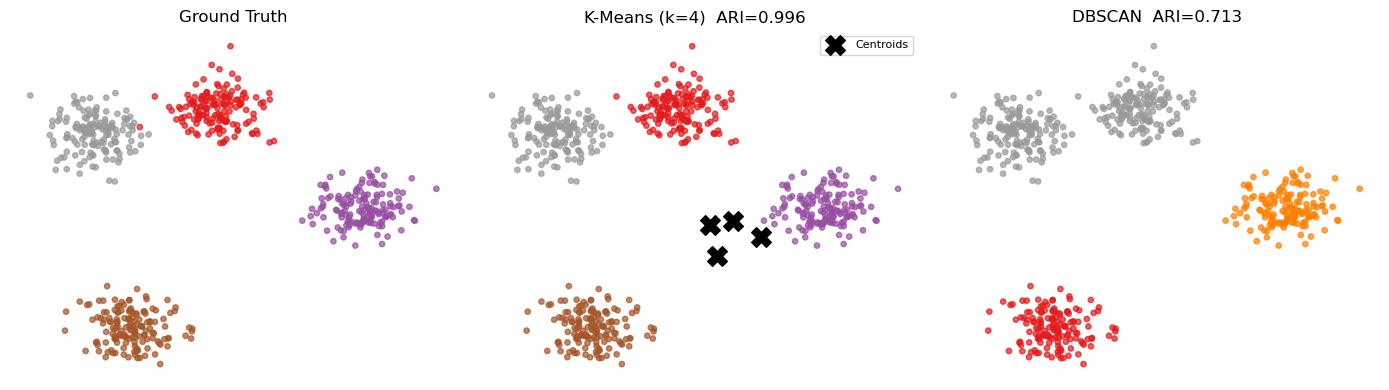

In [9]:
# ── 2.3  K-Means vs DBSCAN Visualisation ─────────────────────────────────────
km4    = KMeans(n_clusters=4, random_state=42, n_init=10).fit(X_sc)
dbscan = DBSCAN(eps=0.4, min_samples=10).fit(X_sc)

print(f'K-Means  — ARI: {adjusted_rand_score(y_true, km4.labels_):.4f}')
print(f'DBSCAN   — ARI: {adjusted_rand_score(y_true, dbscan.labels_):.4f}')
print(f'DBSCAN noise points: {(dbscan.labels_ == -1).sum()}')

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
cmap = plt.cm.Set1

axes[0].scatter(X_blobs[:, 0], X_blobs[:, 1], c=y_true, cmap=cmap, s=15, alpha=0.7)
axes[0].set_title('Ground Truth')

axes[1].scatter(X_blobs[:, 0], X_blobs[:, 1], c=km4.labels_, cmap=cmap, s=15, alpha=0.7)
axes[1].scatter(km4.cluster_centers_[:, 0] * X_sc.std(0)[0] + X_sc.mean(0)[0],
                km4.cluster_centers_[:, 1] * X_sc.std(0)[1] + X_sc.mean(0)[1],
                marker='X', s=200, c='black', zorder=5, label='Centroids')
axes[1].set_title(f'K-Means (k=4)  ARI={adjusted_rand_score(y_true,km4.labels_):.3f}')
axes[1].legend(fontsize=8)

axes[2].scatter(X_blobs[:, 0], X_blobs[:, 1], c=dbscan.labels_, cmap=cmap, s=15, alpha=0.7)
axes[2].set_title(f'DBSCAN  ARI={adjusted_rand_score(y_true,dbscan.labels_):.3f}')

for ax in axes: ax.axis('off')
plt.tight_layout(); plt.show()

In [10]:
# ── 2.4  Cluster Wine Dataset (real data) ────────────────────────────────────
wine = load_wine(as_frame=True)
Xw   = StandardScaler().fit_transform(wine.data)

km_wine = KMeans(n_clusters=3, random_state=42, n_init=10).fit(Xw)
print(f'Wine clustering ARI  : {adjusted_rand_score(wine.target, km_wine.labels_):.4f}')
print(f'Wine silhouette score: {silhouette_score(Xw, km_wine.labels_):.4f}')

# Cross-tabulate cluster vs true label
ct = pd.crosstab(km_wine.labels_, wine.target,
                 rownames=['Cluster'], colnames=['True class'])
print('\nCluster vs True class:')
print(ct)

Wine clustering ARI  : 0.8975
Wine silhouette score: 0.2849

Cluster vs True class:
True class   0   1   2
Cluster               
0            0  65   0
1            0   3  48
2           59   3   0


Components for 95% variance: 10
2D variance explained: 55.41%


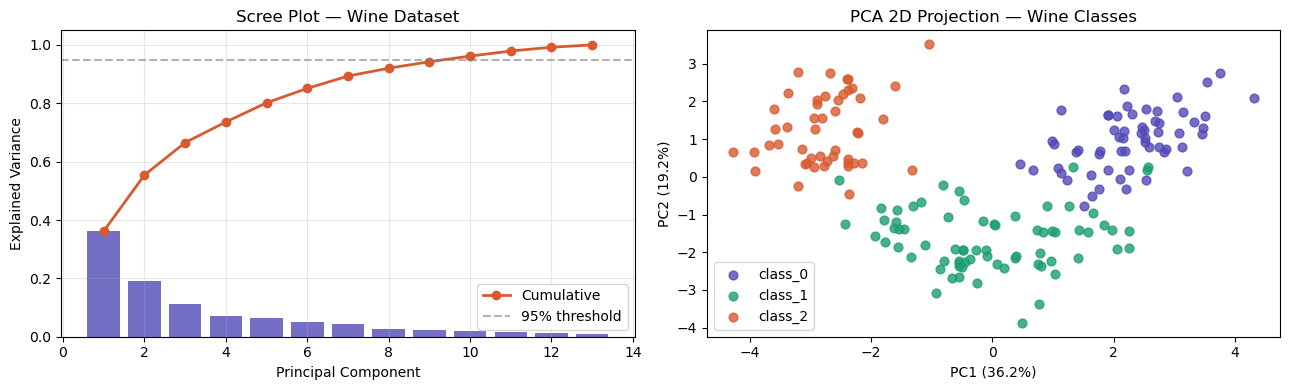

In [11]:
# ── 3.1  PCA on Wine Dataset ──────────────────────────────────────────────────
from sklearn.decomposition import PCA

wine  = load_wine(as_frame=True)
X_w   = StandardScaler().fit_transform(wine.data)

# Fit PCA with all components first
pca_full = PCA().fit(X_w)
cum_var  = np.cumsum(pca_full.explained_variance_ratio_)

# How many components for 95% variance?
n95 = np.argmax(cum_var >= 0.95) + 1
print(f'Components for 95% variance: {n95}')

# Project to 2D for visualisation
pca2d  = PCA(n_components=2)
X2d    = pca2d.fit_transform(X_w)
print(f'2D variance explained: {pca2d.explained_variance_ratio_.sum():.2%}')

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Scree plot
axes[0].bar(range(1, len(pca_full.explained_variance_ratio_)+1),
            pca_full.explained_variance_ratio_, color='#534AB7', alpha=0.8)
axes[0].plot(range(1, len(cum_var)+1), cum_var, 'o-', color='#D85A30', linewidth=2, label='Cumulative')
axes[0].axhline(0.95, linestyle='--', color='gray', alpha=0.6, label='95% threshold')
axes[0].set_xlabel('Principal Component'); axes[0].set_ylabel('Explained Variance')
axes[0].set_title('Scree Plot — Wine Dataset')
axes[0].legend(); axes[0].grid(alpha=0.3)

# 2D projection
colors = ['#534AB7', '#1D9E75', '#D85A30']
for cls in range(3):
    mask = wine.target == cls
    axes[1].scatter(X2d[mask, 0], X2d[mask, 1], c=colors[cls],
                    label=wine.target_names[cls], s=40, alpha=0.8)
axes[1].set_xlabel(f'PC1 ({pca2d.explained_variance_ratio_[0]:.1%})')
axes[1].set_ylabel(f'PC2 ({pca2d.explained_variance_ratio_[1]:.1%})')
axes[1].set_title('PCA 2D Projection — Wine Classes')
axes[1].legend()
plt.tight_layout(); plt.show()

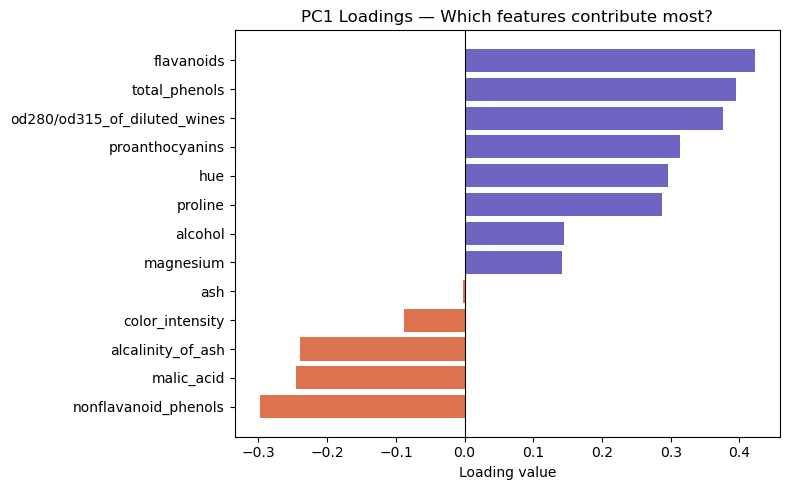

In [12]:
# ── 3.2  PCA Loadings — Which Features Drive PC1? ────────────────────────────
loadings = pd.DataFrame(
    pca2d.components_.T,
    index=wine.feature_names,
    columns=['PC1', 'PC2']
).sort_values('PC1')

fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(loadings.index, loadings['PC1'],
        color=['#534AB7' if v > 0 else '#D85A30' for v in loadings['PC1']], alpha=0.85)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('PC1 Loadings — Which features contribute most?')
ax.set_xlabel('Loading value')
plt.tight_layout(); plt.show()

In [13]:
# ── 3.3  Anomaly Detection: IsolationForest + LocalOutlierFactor ──────────────
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor

# Inject synthetic anomalies into wine data
rng = np.random.default_rng(42)
X_anom = np.vstack([X_w, rng.uniform(-5, 5, (15, X_w.shape[1]))])
true_labels = np.array([1]*len(X_w) + [-1]*15)  # -1 = anomaly

# IsolationForest
iso   = IsolationForest(contamination=0.07, random_state=42)
iso_pred = iso.fit_predict(X_anom)

# LocalOutlierFactor
lof      = LocalOutlierFactor(n_neighbors=20, contamination=0.07)
lof_pred = lof.fit_predict(X_anom)

from sklearn.metrics import classification_report
print('=== IsolationForest ===')
print(f'Anomalies detected: {(iso_pred == -1).sum()}')
print(classification_report(true_labels, iso_pred, target_names=['Normal', 'Anomaly']))

print('=== LocalOutlierFactor ===')
print(f'Anomalies detected: {(lof_pred == -1).sum()}')
print(classification_report(true_labels, lof_pred, target_names=['Normal', 'Anomaly']))

=== IsolationForest ===
Anomalies detected: 14
              precision    recall  f1-score   support

      Normal       1.00      0.93      0.97        15
     Anomaly       0.99      1.00      1.00       178

    accuracy                           0.99       193
   macro avg       1.00      0.97      0.98       193
weighted avg       0.99      0.99      0.99       193

=== LocalOutlierFactor ===
Anomalies detected: 14
              precision    recall  f1-score   support

      Normal       1.00      0.93      0.97        15
     Anomaly       0.99      1.00      1.00       178

    accuracy                           0.99       193
   macro avg       1.00      0.97      0.98       193
weighted avg       0.99      0.99      0.99       193



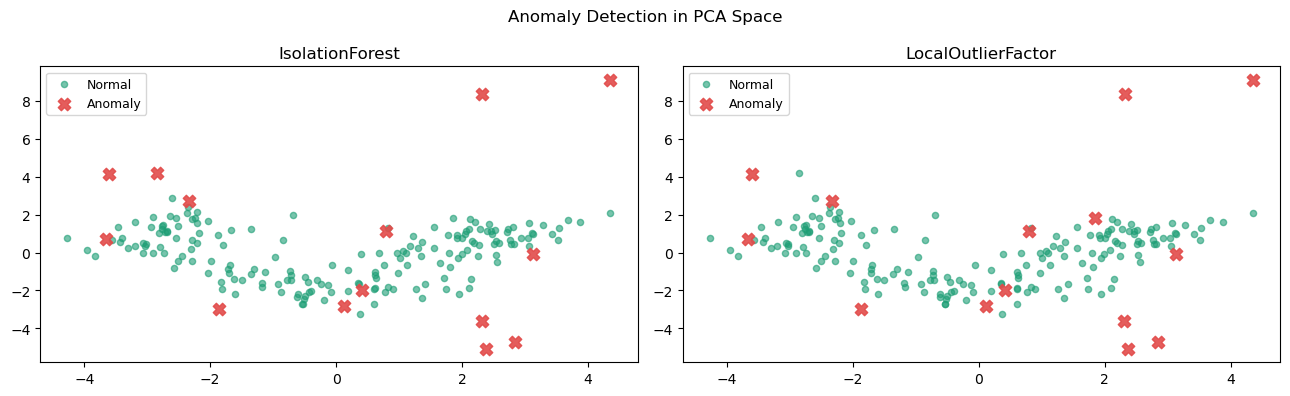

In [14]:
# ── 3.4  Visualise Anomalies in 2D PCA Space ─────────────────────────────────
pca_anom = PCA(n_components=2).fit_transform(X_anom)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for ax, pred, title in zip(axes, [iso_pred, lof_pred],
                            ['IsolationForest', 'LocalOutlierFactor']):
    normal  = pred == 1
    anomaly = pred == -1
    ax.scatter(pca_anom[normal,  0], pca_anom[normal,  1],
               c='#1D9E75', s=20, alpha=0.6, label='Normal')
    ax.scatter(pca_anom[anomaly, 0], pca_anom[anomaly, 1],
               c='#E24B4A', s=80, marker='X', alpha=0.9, label='Anomaly')
    ax.set_title(title); ax.legend(fontsize=9)
plt.suptitle('Anomaly Detection in PCA Space', fontsize=12)
plt.tight_layout(); plt.show()

In [15]:
# ── 3.5  LIME: Explain a Single Prediction ───────────────────────────────────
try:
    import lime
    import lime.lime_tabular

    from sklearn.ensemble import RandomForestClassifier
    wine = load_wine(as_frame=True)
    Xw, yw = wine.data.values, wine.target

    X_tr, X_te, y_tr, y_te = train_test_split(Xw, yw, test_size=0.2, random_state=42)
    rf = RandomForestClassifier(n_estimators=100, random_state=42).fit(X_tr, y_tr)
    print(f'RF accuracy: {rf.score(X_te, y_te):.4f}')

    # Build LIME explainer
    explainer = lime.lime_tabular.LimeTabularExplainer(
        X_tr,
        feature_names=list(wine.feature_names),
        class_names=list(wine.target_names),
        mode='classification'
    )

    # Explain one test sample
    idx = 5
    explanation = explainer.explain_instance(
        X_te[idx], rf.predict_proba, num_features=8
    )

    true_cls = wine.target_names[y_te[idx]]
    pred_cls = wine.target_names[rf.predict([X_te[idx]])[0]]
    print(f'\nSample {idx}: True={true_cls}, Predicted={pred_cls}')
    print('\nLIME top feature contributions:')
    for feat, weight in explanation.as_list():
        direction = '+' if weight > 0 else '-'
        bar = '|' * int(abs(weight) * 20)
        print(f'  [{direction}] {feat:35s} {weight:+.4f}  {bar}')

except ImportError:
    print('Install lime: pip install lime')
    print('Showing manual feature importance instead:')
    from sklearn.ensemble import RandomForestClassifier
    wine = load_wine(as_frame=True)
    rf = RandomForestClassifier(100, random_state=42).fit(wine.data, wine.target)
    imp = sorted(zip(wine.feature_names, rf.feature_importances_), key=lambda x: -x[1])
    for f, i in imp[:6]:
        print(f'  {f:30s} {i:.4f}')

Install lime: pip install lime
Showing manual feature importance instead:
  flavanoids                     0.1945
  color_intensity                0.1730
  alcohol                        0.1416
  proline                        0.1370
  od280/od315_of_diluted_wines   0.1118
  hue                            0.0769


In [16]:
# ── 3.6  LIME Bar Chart ───────────────────────────────────────────────────────
try:
    items     = explanation.as_list()[:8]
    feat_lbls = [i[0][:30] for i in items]
    weights   = [i[1] for i in items]
    colors    = ['#1D9E75' if w > 0 else '#E24B4A' for w in weights]

    fig, ax = plt.subplots(figsize=(9, 4))
    ax.barh(feat_lbls, weights, color=colors, alpha=0.85)
    ax.axvline(0, color='black', linewidth=0.8)
    ax.set_title(f'LIME Explanation — Sample {idx} (True: {true_cls}, Pred: {pred_cls})')
    ax.set_xlabel('Feature contribution')
    plt.tight_layout(); plt.show()
except:
    print('Skipping LIME plot — lime not installed')

Skipping LIME plot — lime not installed


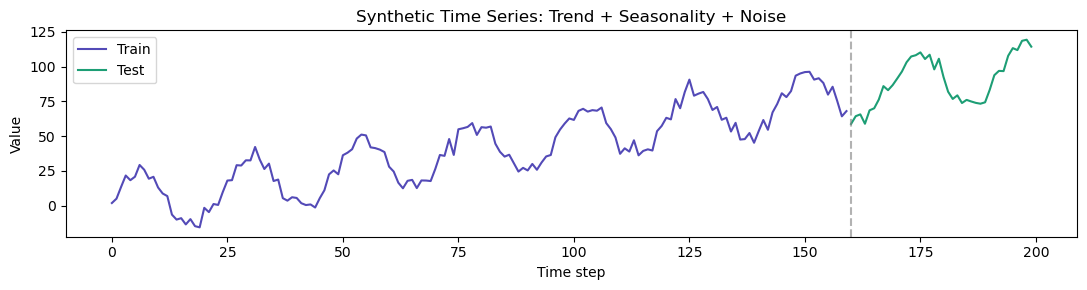

In [17]:
# ── 5.1  Generate Synthetic Time Series ──────────────────────────────────────
np.random.seed(42)
t  = np.arange(200)
# trend + seasonality + noise
ts = 0.5 * t + 20 * np.sin(2 * np.pi * t / 24) + np.random.normal(0, 4, 200)

train_ts = ts[:160]
test_ts  = ts[160:]

fig, ax = plt.subplots(figsize=(11, 3))
ax.plot(t[:160], train_ts, label='Train', color='#534AB7')
ax.plot(t[160:], test_ts,  label='Test',  color='#1D9E75')
ax.axvline(160, linestyle='--', color='gray', alpha=0.6)
ax.set_title('Synthetic Time Series: Trend + Seasonality + Noise')
ax.set_xlabel('Time step'); ax.set_ylabel('Value')
ax.legend(); plt.tight_layout(); plt.show()

In [18]:
# ── 5.2  ARIMA Forecast ───────────────────────────────────────────────────────
from statsmodels.tsa.arima.model import ARIMA

# ARIMA(p=2, d=1, q=2): AR lags, 1 differencing, MA terms
model = ARIMA(train_ts, order=(2, 1, 2))
fitted = model.fit()

# Forecast 40 steps ahead
forecast_result = fitted.get_forecast(steps=40)
fc_mean  = forecast_result.predicted_mean
fc_ci    = forecast_result.conf_int(alpha=0.05)

rmse = np.sqrt(mean_squared_error(test_ts, fc_mean))
mae  = np.mean(np.abs(test_ts - fc_mean))
print(f'ARIMA(2,1,2) — RMSE: {rmse:.3f} | MAE: {mae:.3f}')
print(fitted.summary().tables[0])

ARIMA(2,1,2) — RMSE: 38.230 | MAE: 33.964
                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                  160
Model:                 ARIMA(2, 1, 2)   Log Likelihood                -503.266
Date:                Wed, 25 Mar 2026   AIC                           1016.533
Time:                        11:27:35   BIC                           1031.877
Sample:                             0   HQIC                          1022.764
                                - 160                                         
Covariance Type:                  opg                                         


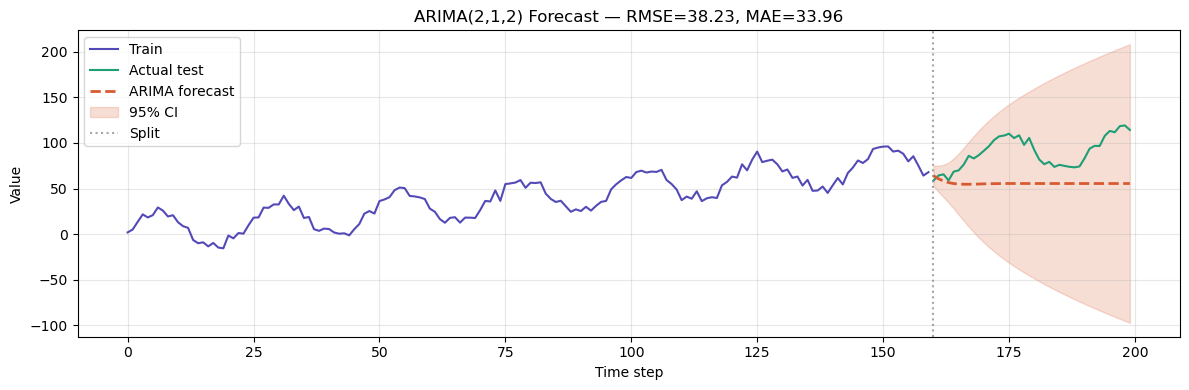

In [20]:
import matplotlib.pyplot as plt
import numpy as np

# Ensure everything is aligned (optional but safe)
t_test = t[160:]

# Convert forecast outputs to numpy (in case they are pandas)
fc_mean_vals = np.asarray(fc_mean)
fc_ci_vals = np.asarray(fc_ci)

# ── Plot Forecast with Confidence Interval ───────────────────────────────
fig, ax = plt.subplots(figsize=(12, 4))

# Train data
ax.plot(t[:160], train_ts, color='#534AB7', linewidth=1.5, label='Train')

# Actual test data
ax.plot(t[160:], test_ts, color='#1D9E75', linewidth=1.5, label='Actual test')

# Forecast
ax.plot(t_test, fc_mean_vals, color='#D85A30', linewidth=2,
        linestyle='--', label='ARIMA forecast')

# Confidence interval (FIXED HERE)
ax.fill_between(
    t_test,
    fc_ci_vals[:, 0],   # lower bound
    fc_ci_vals[:, 1],   # upper bound
    alpha=0.2,
    color='#D85A30',
    label='95% CI'
)

# Train/Test split line
ax.axvline(160, linestyle=':', color='gray', alpha=0.7, label='Split')

# Labels and title
ax.set_title(f'ARIMA(2,1,2) Forecast — RMSE={rmse:.2f}, MAE={mae:.2f}')
ax.set_xlabel('Time step')
ax.set_ylabel('Value')

# Styling
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [21]:
# ── 5.4  Time Series Feature Engineering ────────────────────────────────────
# Extract rolling stats as features for ML models
ts_df = pd.DataFrame({'value': ts})
ts_df['lag1']    = ts_df['value'].shift(1)
ts_df['lag2']    = ts_df['value'].shift(2)
ts_df['lag12']   = ts_df['value'].shift(12)
ts_df['roll_mean_6']  = ts_df['value'].rolling(6).mean()
ts_df['roll_std_6']   = ts_df['value'].rolling(6).std()
ts_df['roll_max_12']  = ts_df['value'].rolling(12).max()
ts_df = ts_df.dropna()

print('Feature-engineered DataFrame shape:', ts_df.shape)
print(ts_df.head())

Feature-engineered DataFrame shape: (188, 7)
        value      lag1       lag2      lag12  roll_mean_6  roll_std_6  \
12   6.967849  8.813462  13.146329   1.986857    15.845147    7.402888   
13  -6.329502  6.967849   8.813462   5.123324    10.475521    9.918341   
14  -9.899671 -6.329502   6.967849  13.590754     5.585140   11.688561   
15  -8.891286 -9.899671  -6.329502  21.734255     0.634530   10.136659   
16 -13.371833 -8.891286  -9.899671  18.383895    -3.785163    9.340131   

    roll_max_12  
12    29.316851  
13    29.316851  
14    29.316851  
15    29.316851  
16    29.316851  


In [23]:
# ── 5.5 VotingClassifier: Hard vs Soft Voting ───────────────────────────────
from sklearn.datasets import load_breast_cancer
from sklearn.ensemble import VotingClassifier, GradientBoostingClassifier, RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.model_selection import cross_val_score

# Load dataset
bc = load_breast_cancer()
X_bc, y_bc = bc.data, bc.target

# Base estimators
estimators = [
    ('rf', RandomForestClassifier(n_estimators=50, random_state=42)),
    ('gb', GradientBoostingClassifier(n_estimators=50, random_state=42)),
    ('lr', LogisticRegression(max_iter=500))
]

# Hard voting (majority vote)
hard = VotingClassifier(estimators=estimators, voting='hard')

# Soft voting (probability averaging)
svc_prob = SVC(probability=True, random_state=42)
soft_ests = estimators + [('svc', svc_prob)]
soft = VotingClassifier(estimators=soft_ests, voting='soft')

# Evaluation
results_vote = {}

for name, clf in [
    ('Hard Voting', hard),
    ('Soft Voting', soft),
    ('RF alone', RandomForestClassifier(n_estimators=50, random_state=42)),
    ('GB alone', GradientBoostingClassifier(n_estimators=50, random_state=42))
]:
    scores = cross_val_score(clf, X_bc, y_bc, cv=5, scoring='accuracy')
    results_vote[name] = scores
    print(f'{name:18s}: {scores.mean():.4f} ± {scores.std():.4f}')

Hard Voting       : 0.9613 ± 0.0204
Soft Voting       : 0.9701 ± 0.0197
RF alone          : 0.9543 ± 0.0244
GB alone          : 0.9596 ± 0.0142


In [24]:
# ── 5.6  StackingClassifier with Meta-Learner ────────────────────────────────
from sklearn.ensemble import StackingClassifier

base_learners = [
    ('rf', RandomForestClassifier(n_estimators=50, random_state=42)),
    ('gb', GradientBoostingClassifier(n_estimators=50, random_state=42)),
    ('lr', LogisticRegression(max_iter=500)),
]
# Meta-learner trains on out-of-fold predictions from base models
meta_learner = LogisticRegression(max_iter=500)

stack = StackingClassifier(
    estimators=base_learners,
    final_estimator=meta_learner,
    cv=3,
    passthrough=False  # only meta-features fed to final estimator
)

stack_scores = cross_val_score(stack, X_bc, y_bc, cv=5, scoring='accuracy')
print(f'StackingClassifier: {stack_scores.mean():.4f} ± {stack_scores.std():.4f}')

StackingClassifier: 0.9701 ± 0.0131


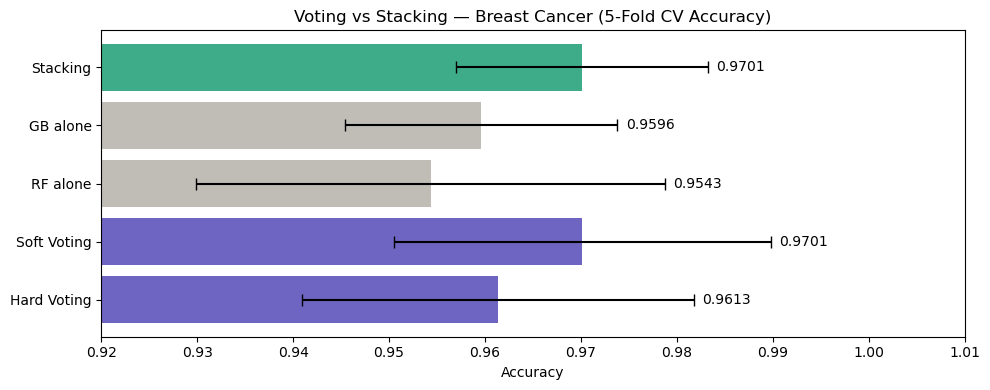

In [25]:
# ── 5.7  Full Model Comparison Chart ────────────────────────────────────────
all_results = {**results_vote, 'Stacking': stack_scores}
names  = list(all_results.keys())
means  = [v.mean() for v in all_results.values()]
stds   = [v.std()  for v in all_results.values()]
colors = ['#534AB7','#534AB7','#B4B2A9','#B4B2A9','#1D9E75']

fig, ax = plt.subplots(figsize=(10, 4))
bars = ax.barh(names, means, xerr=stds, color=colors, alpha=0.85,
               capsize=4, error_kw={'linewidth': 1.5})
ax.bar_label(bars, labels=[f'{m:.4f}' for m in means], padding=6, fontsize=10)
ax.set_xlim(0.92, 1.01)
ax.set_title('Voting vs Stacking — Breast Cancer (5-Fold CV Accuracy)')
ax.set_xlabel('Accuracy')
plt.tight_layout(); plt.show()

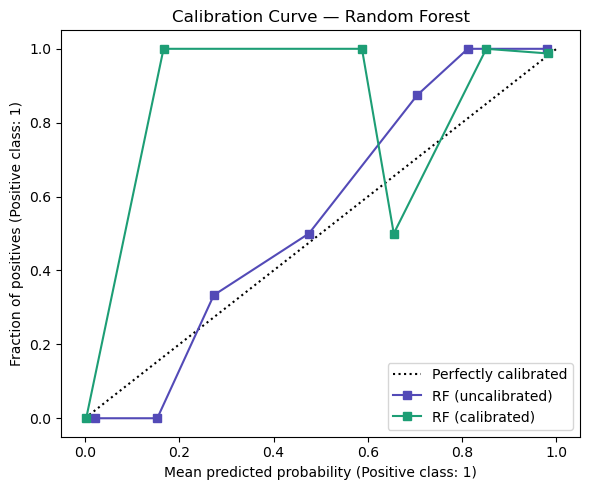

Well-calibrated = diagonal line


In [26]:
# ── 5.8  Probability Calibration ─────────────────────────────────────────────
from sklearn.calibration import CalibratedClassifierCV, CalibrationDisplay

X_tr, X_te, y_tr, y_te = train_test_split(X_bc, y_bc, test_size=0.25, random_state=42)

rf_base = RandomForestClassifier(n_estimators=50, random_state=42).fit(X_tr, y_tr)
rf_cal  = CalibratedClassifierCV(
    RandomForestClassifier(n_estimators=50, random_state=42),
    method='isotonic', cv=3
).fit(X_tr, y_tr)

fig, ax = plt.subplots(figsize=(6, 5))
CalibrationDisplay.from_estimator(rf_base, X_te, y_te, n_bins=8,
                                   name='RF (uncalibrated)', ax=ax, color='#534AB7')
CalibrationDisplay.from_estimator(rf_cal,  X_te, y_te, n_bins=8,
                                   name='RF (calibrated)',   ax=ax, color='#1D9E75')
ax.set_title('Calibration Curve — Random Forest')
plt.tight_layout(); plt.show()
print('Well-calibrated = diagonal line')